# Métropole du Grand Nancy

# 0. Configuration

In [1]:
import os
import sys
import numpy as np
import geopandas as gpd
import ee
import matplotlib.pyplot as plt

# personal modules
sys.path.insert(1, '../../marion/corridor_project/modules/')
import landcover as lc
import connectivity as conn
import routing as rout
sys.path.insert(1, '../../marion/corridor_project/config/')
import species_params

# Authentification GEE
service_account = 'gee-141@gee161025.iam.gserviceaccount.com'
credentials_path = '../../marion/credentials/gee161025-533af22f806b.json'
credentials = ee.ServiceAccountCredentials(service_account, credentials_path)
ee.Initialize(credentials)

# case study def
CITY = "Nancy"
GUILD_KEY = "mid_walker"
specie = species_params.SPECIES_CONFIG[GUILD_KEY]
OUTPUT_DIR = f"/home/jovyan/work/team/marion/corridor_project/results_connectivity/{CITY}"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Paramètres AOI
url_aoi = "https://geo.api.gouv.fr/epcis?nom=Grand%20Nancy&format=geojson&geometry=contour"
aoi_raw = gpd.read_file(url_aoi)
dept = "D054"

Matplotlib created a temporary cache directory at /tmp/matplotlib-yfm84zst because the default path (/home/jovyan/.cache/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.
/home/jovyan/.local/lib/python3.11/site-packages/xarray/backends/scipy_.py:39: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.4.3)
  from scipy.io import netcdf_file as netcdf_file_base
Skipping field codesDepartements: unsupported OGR type: 5
Skipping field codesRegions: unsupported OGR type: 5


In [33]:
import importlib
from modules import landcover as lc
from modules import connectivity as conn
from modules import routing as rout
import species_params
importlib.reload(lc)
importlib.reload(conn)
importlib.reload(rout)
importlib.reload(species_params)

<module 'species_params' from '/home/jovyan/work/team/marion/corridor_project/../../marion/corridor_project/config/species_params.py'>

# 1. Landcover

Landcover raster combining ESA WorldCover and OSM Highways

In [3]:
aoi_utm, aoi_ee, utm_epsg = lc.setup_aoi(aoi_raw)
da_lc = lc.get_city_landcover(aoi_ee, aoi_utm, aoi_raw, utm_epsg)
print(f"Valeurs : {np.unique(da_lc.values)}")

# da_export = da_lc.fillna(0).astype('uint8')
# da_export.rio.to_raster(f"{OUTPUT_DIR}/landcover_{CITY}.tif")

/home/jovyan/.local/lib/python3.11/site-packages/xee/ext.py:696: UserWarning: Unable to retrieve 'system:time_start' values from an ImageCollection due to: No 'system:time_start' values found in the 'ImageCollection'.
  warnings.warn(


Valeurs : [10. 30. 40. 50. 51. 52. 60. 80. 90. nan]


# 2. Habitat Morphology - MSPA

Identifies morphological connectivity elements (nodes and stepping stones) based on species preferences

In [4]:
habitat_codes = specie['habitat_codes']
binary_wc = conn.get_binary_habitat(da_lc, habitat_codes)

gdf_cores, gdf_islets = conn.get_connectivity_elements(binary_wc, core_min_ha=1.0, islet_min_ha=0.2)
print(f"✓ {len(gdf_cores)} Noyaux de biodiversité et {len(gdf_islets)} Stepping Stones (Islets + Petits Cores) identifiés.")

# binary_wc.rio.to_raster(f"{OUTPUT_DIR}/binary_habitat_{CITY}.tif")
# gdf_cores.set_crs(utm_epsg, inplace=True, allow_override=True)
# gdf_islets.set_crs(utm_epsg, inplace=True, allow_override=True)
# gdf_cores.to_file(f"{OUTPUT_DIR}/cores_{CITY}.json", driver='GeoJSON')
# gdf_islets.to_file(f"{OUTPUT_DIR}/islets_{CITY}.json", driver='GeoJSON')

✓ 363 Noyaux de biodiversité et 723 Stepping Stones (Islets + Petits Cores) identifiés.


# 3. Graph Connectivity Analysis

## 3.1. Network modeling

The landscape is modeled as a graph where Nodes represent habitat patches and Edges represent potential dispersal links.
- Probabilistic approach: Connection strength is based on an exponential decay function relative to the species dispersal distance ($d_0$) - probability of movement between patches.
- Topology: Edges are identified using a K-Nearest Neighbors (KNN) algorithm, where the $k$ set increases with the species dispersal capabilities.

In [ ]:
df_nodes = conn.prepare_graph_nodes(gdf_cores, gdf_islets)
G = conn.build_connectivity_graph_knn(df_nodes, specie)

## 3.2. Theoretical PC index

Probability of Connectivity (PC) Index measures landscape permeability for a given functional guild. It represents the probability that 2 points randomly placed in the city fall within connected habitat patches.

In [ ]:
total_area_km2 = aoi_utm.area.sum() / 1e6
pc_value = conn.calculate_pc_index(G, total_area_km2)
print(f"Indice PC pour {CITY} : {pc_value:.6f}")

gdf_edges = conn.graph_to_gdf_edges(G, utm_epsg)
# gdf_edges.to_file(f"{OUTPUT_DIR}/edges_{CITY}.json", driver='GeoJSON')

# 4. Least Cost Path Analysis

From euclidean distance to real-world distance that accounts for landscape friction. Simulation of the optimal path for a given species between each node.

In [6]:
gdf_lcp = rout.compute_lcp_network(gdf_edges, df_nodes, da_lc, specie['friction'])

gdf_lcp['tortuosity'] = gdf_lcp['real_dist'] / gdf_lcp['theoretical_dist']
print(f"Average Tortuosity for {CITY}: {gdf_lcp['tortuosity'].mean():.3f}")

Tracing LCPs: 100%|██████████| 5201/5201 [03:27<00:00, 25.01it/s]


Average Tortuosity for Nancy: 1.729


## 4.1. Network metrics: PC

By comparing the Theoretical PC (Euclidean from Graph) with the Real PC (LCP), we quantify the connectivity loss. This delta quantifies the impact of human infrastructure and urban matrix on species mobility.

In [14]:
pc_real, G_lcp = conn.calculate_pc_index_lcp(G=G, total_area_km2=total_area_km2, species_params=specie, gdf_lcp=gdf_lcp)
print(f"Theoretical PC (euclidian) : {pc_value:.6f}")
print(f"Real PC (LCP) : {pc_real:.6f}")
print(f"Fragmentation impact : {((pc_value - pc_real) / pc_value)*100:.1f}% connectivity loss.")

Indice PC Théorique : 0.013755
Indice PC Réel : 0.010655
Impact de la fragmentation : 22.5% de perte.


## 4.2. Corridors metrics: dPC, ebc

Identify critical links for network maintenance using two complementary metrics: 
- dPC (Flux): Ranks corridors by the volume of biodiversity flow they facilitate, based on the surface area of the habitats they connect. Network highways.
- Edge Betweenness Centrality (Rarity) : Highlights bottlenecks / bridge corridors. Vital for network cohesion, their loss would fragment the system into isolated sub-units.

In [8]:
# dpc flux
gdf_lcp = conn.calculate_edge_dpc(gdf_lcp, G_lcp, total_area_km2, pc_real)

# edge betweenness centrality proxy dpc edge connector
gdf_lcp = conn.calculate_edge_betweenness(gdf_lcp, G_lcp)

### 4.2.1. Corridors categories

| Flow (dPC) | Rarity (EBC) | Corridor category |  
| :--- | :--- | :--- |   
| **High** | **High** | Ecological highway |  
| **Low** | **High** | Strategic bottleneck |  
| **High** | **Low** | Redundant mesh |  
| **Low** | **Low** | Local link |  

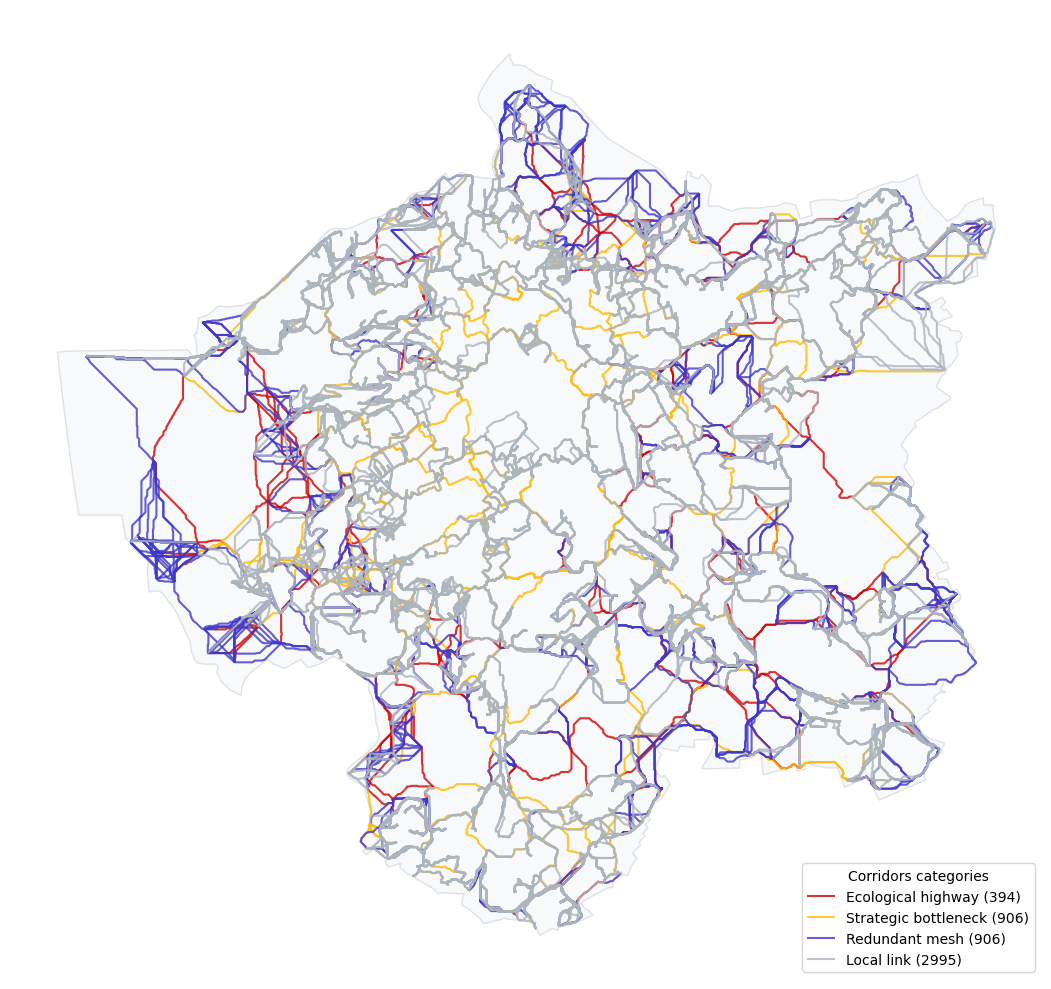

In [46]:
gdf_lcp = conn.classify_and_plot_corridors(gdf_lcp, aoi_utm, 0.75)
#gdf_lcp.to_file(f"{OUTPUT_DIR}/lcp_{CITY}.json", driver='GeoJSON')

In [69]:
import holoviews as hv
from holoviews import opts
hv.extension('bokeh')

def plot_interactive_categories(gdf_lcp, aoi_utm):
    # 1. Préparation des données (HoloViews aime le 4326 pour les fonds de carte)
    gdf_plot = gdf_lcp.to_crs(epsg=4326)
    aoi_plot = aoi_utm.to_crs(epsg=4326)

    # 2. Création des couches par catégorie
    # On crée un dictionnaire de chemins (Paths)
    categories = gdf_plot['category'].unique()
    category_colors = {
        'Ecological highway': '#d00000',
        'Strategic bottleneck': '#ffba08',
        'Redundant mesh': '#3f37c9',
        'Local link': '#adb5bd'
    }

    layers = []
    for cat in categories:
        subset = gdf_plot[gdf_plot['category'] == cat]
        # Création de l'élément Path pour HoloViews
        path = hv.Path(subset, label=cat).opts(
            color=category_colors.get(cat, 'black'),
            line_width=2 if cat != 'Local link' else 1,
            alpha=0.8 if cat != 'Local link' else 0.4,
            tools=['hover'] # Affiche les infos au survol
        )
        layers.append(path)

    # 3. Fond de carte (Optionnel, nécessite geoviews) et Overlay
    layout = hv.Overlay(layers).opts(
        title=f"Diagnostic des Corridors - {CITY}",
        width=800,
        height=600,
        legend_position='right',
        show_grid=False
    )

    return layout

# Affichage
plot_interactive_categories(gdf_lcp, aoi_utm)

ModuleNotFoundError: No module named 'holoviews'

## 4.3. Nodes metrics: dPC

Analysis of the contribution of each patch to the global network. Connector fraction of the dPC index, which identifies patches that act as essential topological relays between other nodes, regardless of their own intrinsic area.
> warning : very long to compute, iterative node-removal simulations.

In [15]:
# df_nodes_connector = conn.calculate_node_dpc(G_lcp, total_area_km2, species_params=specie)
# gdf_nodes = df_nodes.merge(df_nodes_connector, left_index=True, right_on='node_id')
# gdf_nodes.set_crs(utm_epsg, inplace=True, allow_override=True)
# gdf_nodes.to_file(f"{OUTPUT_DIR}/dpc_nodes_{CITY}.json", driver='GeoJSON')

Analyse de connectivité pour 1086 noyaux...


Calcul dPC Nodes: 100%|██████████| 1086/1086 [3:58:29<00:00, 13.18s/node] 
/opt/conda/lib/python3.11/site-packages/pyogrio/raw.py:698: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  warnings.warn(


______
# ***WIP***

# 5. Circuit Theory

Proxy flou gaussien au lieu de lois de Kirchoff résistance pour chaque pixel  
Définir les sources et les grounds  

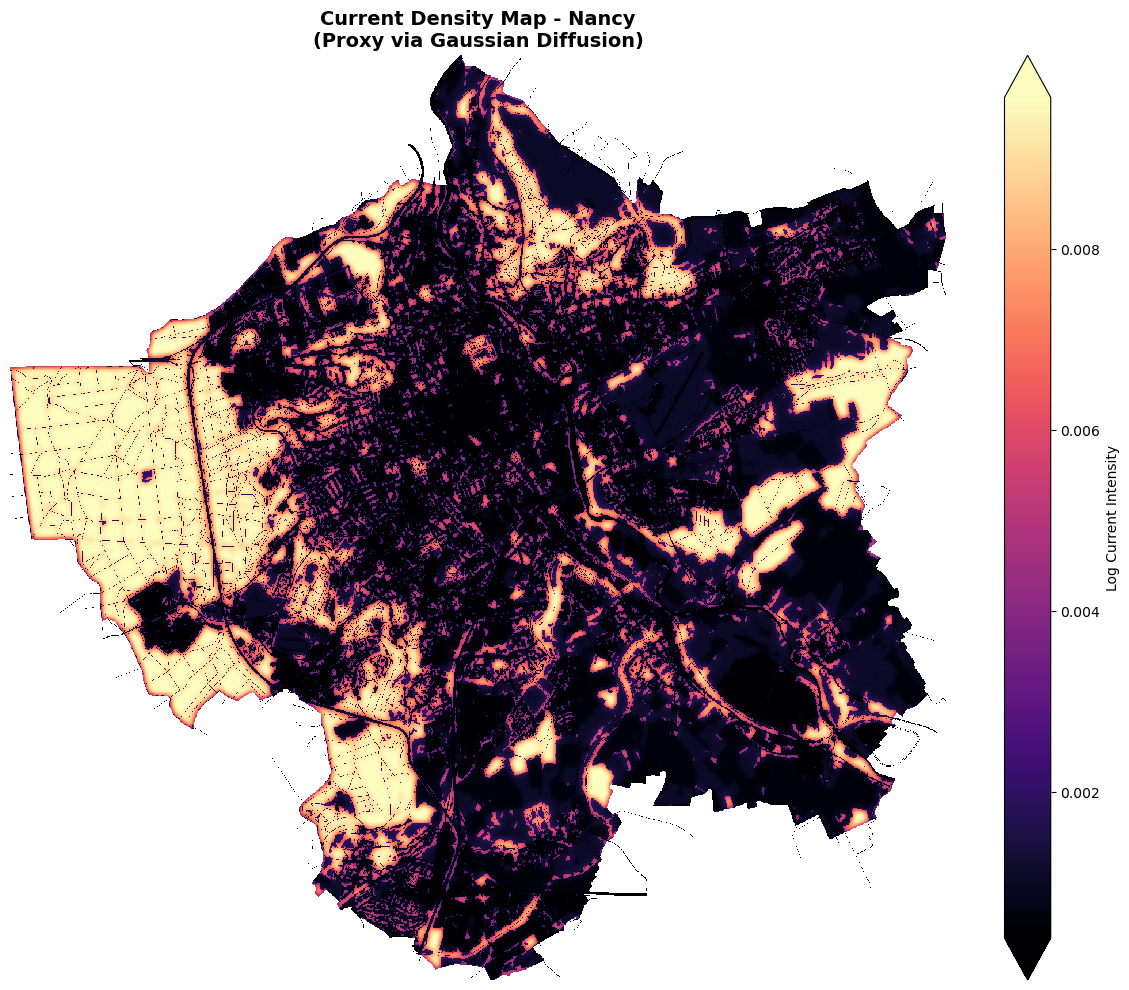

In [65]:
from scipy.ndimage import gaussian_filter

def calculate_pinch_points_proxy(da_friction, sigma=5):
    # Gestion des NaNs
    mask = da_friction.isnull()
    clean_friction = da_friction.fillna(da_friction.max())
    
    # 1. Conductance (Inverse de la friction)
    conductance = 1.0 / (clean_friction + 0.1)
    
    # 2. Diffusion proxy (Sigma plus élevé pour mieux voir les corridors)
    flow_spread = gaussian_filter(conductance.values, sigma=sigma)
    
    # Intensité de courant
    current_density = flow_spread * conductance.values
    
    da_current = da_friction.copy(data=current_density)
    return da_current.where(~mask)

# 1. Calcul
da_current_map = calculate_pinch_points_proxy(da_lc, sigma=5)

# 2. Visualisation simple
fig, ax = plt.subplots(figsize=(12, 10))

# On utilise log1p pour compresser la dynamique et voir les détails urbains
np.log1p(da_current_map).plot(
    ax=ax, 
    cmap='magma', 
    robust=True, 
    cbar_kwargs={'label': 'Log Current Intensity'}
)

ax.set_title(f"Current Density Map - {CITY}\n(Proxy via Gaussian Diffusion)", fontsize=14, fontweight='bold')
ax.set_axis_off()

plt.tight_layout()
plt.show()